# LAB 4: Linear Regression - Students

## 0 Import packages

In [1]:
import subprocess
subprocess.run(['pip3', 'install', 'openpyxl'], capture_output=True)

CompletedProcess(args=['pip3', 'install', 'openpyxl'], returncode=0, stdout=b'Requirement already satisfied: openpyxl in /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages (3.1.5)\nRequirement already satisfied: et-xmlfile in /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages (from openpyxl) (2.0.0)\n', stderr=b'\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b A new release of pip is available: \x1b\x1b25.2\x1b\x1b -> \x1b\x1b26.1.1\x1b\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b To update, run: \x1b\x1bpip3 install --upgrade pip\x1b\n')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1 Load and plot the data


[[   31.        336.56            nan]
 [   62.        337.29            nan]
 [   90.        337.88            nan]
 ...
 [15127.        413.81      411.1275 ]
 [15158.        412.88      411.32333]
 [15188.        411.17      411.51416]]


Text(0, 0.5, 'CO2 Concentration (ppm)')

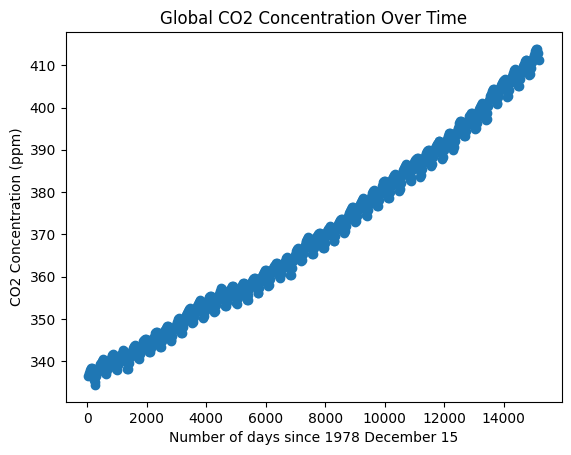

In [3]:
# Read the excel file
file_path = 'global_co2_concentration.xlsx'
data = pd.read_excel(file_path, usecols='B:D', nrows=499)

# Convert the data in a numpy table
tableau_numpy = data.to_numpy()

# Display the table
print(tableau_numpy)

# Display the data cloud
plt.scatter(tableau_numpy[:, 0], tableau_numpy[:, 1])
plt.title('Global CO2 Concentration Over Time')
plt.xlabel('Number of days since 1978 December 15')
plt.ylabel('CO2 Concentration (ppm)')

## 2 Univariate linear regression 

 Correlation coefficient : 0.9927270241841618
Error : 6.859772688468219


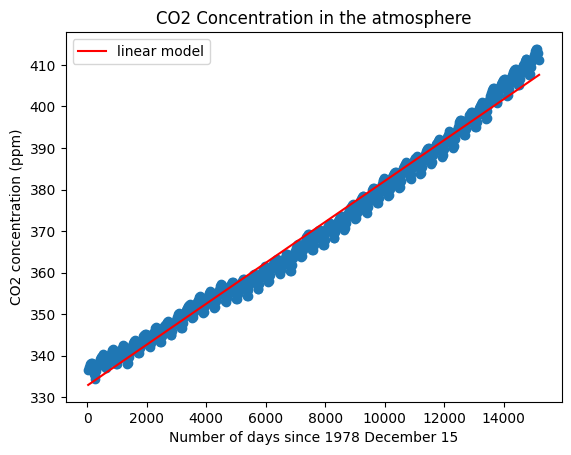

In [5]:
# Define the x and y variables
x = tableau_numpy[:, 0]
y = tableau_numpy[:, 1]

# Compute the coefficients of the linear regression

cov_xy = np.cov(x, y, bias=True)  # 2x2 covariance matrix: [0,1] is cov(x,y), [0,0] is var(x), [1,1] is var(y)
s_x = cov_xy[0, 0]                # variance of x
a = cov_xy[0, 1] / s_x            # slope
b = np.mean(y) - a * np.mean(x)   # intercept

err = np.mean((y - (a * x + b))**2)   # mean square error
r = cov_xy[0, 1] / np.sqrt(cov_xy[0, 0] * cov_xy[1, 1])  # correlation coefficient

# Display the correlation coefficient and the error
print(f" Correlation coefficient : {r}")
print(f"Error : {err}")

# Afficher le nuage de points avec la droite de régression  
plt.scatter(tableau_numpy[:, 0], tableau_numpy[:, 1])
plt.plot(x, a * x + b, color='red', label='linear model')
plt.xlabel('Number of days since 1978 December 15')
plt.ylabel('CO2 concentration (ppm)')
plt.title('CO2 Concentration in the atmosphere')
plt.legend()
plt.show()

Correlation coefficient: 0.9927270241841619
Error: 6.859772688468213


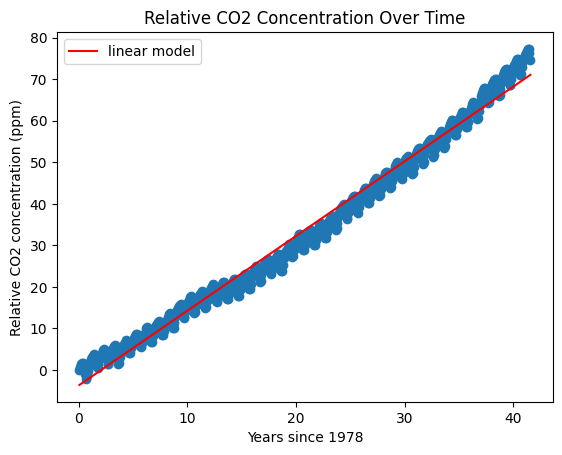

In [6]:
# Define new variables
x_years = x / 365.25                    # convert days to years
y_relative = y - y[0]                   # relative concentration (0 at start)

# Recompute the coefficients of the linear regression for the relative CO2 concentration
cov_xy2 = np.cov(x_years, y_relative, bias=True)
a2 = cov_xy2[0, 1] / cov_xy2[0, 0]
b2 = np.mean(y_relative) - a2 * np.mean(x_years)
err2 = np.mean((y_relative - (a2 * x_years + b2))**2)
r2 = cov_xy2[0, 1] / np.sqrt(cov_xy2[0, 0] * cov_xy2[1, 1])

# Display the coefficients
print(f"Correlation coefficient: {r2}")
print(f"Error: {err2}")

# Plot
plt.scatter(x_years, y_relative)
plt.plot(x_years, a2 * x_years + b2, color='red', label='linear model')
plt.xlabel('Years since 1978')
plt.ylabel('Relative CO2 concentration (ppm)')
plt.title('Relative CO2 Concentration Over Time')
plt.legend()
plt.show()

**Q4** - Conjecture: A linear transformation of x and y does not change the correlation coefficient r. 

**Proof:** r is defined as cov(x,y) / sqrt(var(x) * var(y)).
If we apply x' = x/365.25 and y' = y - y[0], scaling x by a constant c divides both cov(x,y) and std(x) by c, so they cancel out. Shifting y by a constant doesn't affect covariance or variance at all. Therefore r stays the same.

## 3 Analysis of the averaged concentration

Correlation coefficient with averaged data: 0.995407048156004
Error with averaged data: 4.099825754016623


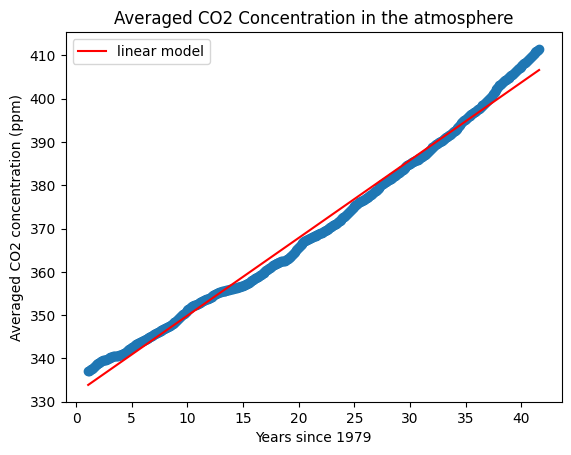

In [8]:
# crop the first year in the data to obtain vectors without Nan values
y_ = tableau_numpy[12:, 2]   # averaged concentration, skip first 12 rows (NaN)
x_ = tableau_numpy[12:, 0] / 365.25  # time in years

# Compute the coefficients of the linear regression for the averaged data
cov_avg = np.cov(x_, y_, bias=True)
a_ = cov_avg[0, 1] / cov_avg[0, 0]
b_ = np.mean(y_) - a_ * np.mean(x_)
err_ = np.mean((y_ - (a_ * x_ + b_))**2)
r_ = cov_avg[0, 1] / np.sqrt(cov_avg[0, 0] * cov_avg[1, 1])

# Display the coefficients for the averaged data
print(f"Correlation coefficient with averaged data: {r_}")
print(f"Error with averaged data: {err_}")

# Plot
plt.scatter(x_, y_)
plt.plot(x_, a_ * x_ + b_, color='red', label='linear model')
plt.xlabel('Years since 1979')
plt.ylabel('Averaged CO2 concentration (ppm)')
plt.title('Averaged CO2 Concentration in the atmosphere')
plt.legend()
plt.show()

**Q5:** the linear model is slightly more relevant for the averaged data than the raw data (lower error, smoother curve), but we can still see the data curves slightly upwards so it's still not perfect.

### 3.1 The exponential model

alpha = 57.05451657528098, beta = 0.020196475606141913
Correlation coefficient: 0.9993838115227169
Error (exponential model): 0.40196834564335493


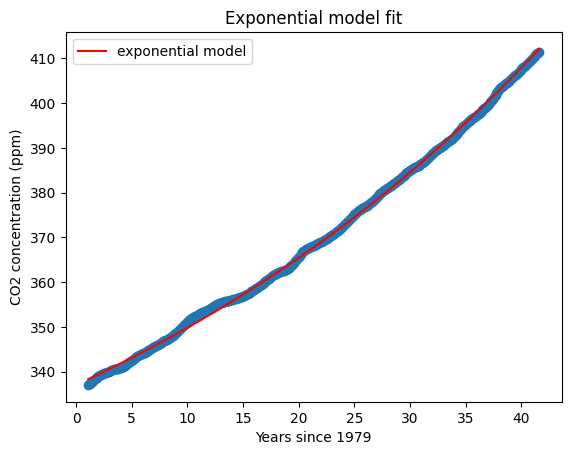

In [9]:
# Transform the averaged data to log scale
y_= np.log(y_ - 280)

# Compute the coefficients of the linear regression on y_aux
cov_exp = np.cov(x_, y_, bias=True)
beta = cov_exp[0, 1] / cov_exp[0, 0]
log_alpha = np.mean(y_) - beta * np.mean(x_)
alpha = np.exp(log_alpha)

r_exp = cov_exp[0, 1] / np.sqrt(cov_exp[0, 0] * cov_exp[1, 1])

# Compute mean error of the exponential model
y_exp_pred = 280 + alpha * np.exp(beta * x_)
err_exp = np.mean((tableau_numpy[12:, 2] - y_exp_pred)**2)

print(f"alpha = {alpha}, beta = {beta}")
print(f"Correlation coefficient: {r_exp}")
print(f"Error (exponential model): {err_exp}")

# Plot
plt.scatter(x_, tableau_numpy[12:, 2])
plt.plot(x_, y_exp_pred, color='red', label='exponential model')
plt.xlabel('Years since 1979')
plt.ylabel('CO2 concentration (ppm)')
plt.title('Exponential model fit')
plt.legend()
plt.show()

**Q6:** if the model holds, then y - 280 = alpha·exp(beta*x), so taking the log of both sides gives:
log(y - 280) = log(alpha) + (beta*x)
This is affine in x, so we define y_aux = log(y - 280).

**Q7:** the exponential model has an error of 0.40 vs 4.1 for the linear model, and r ≈ 0.9993. The exponential model is clearly a much better fit for this data.

### 3.2 The polynomial model


Coefficients of the polynomial fit: [3.36912666e+02 1.12659482e+00 1.57145381e-02]


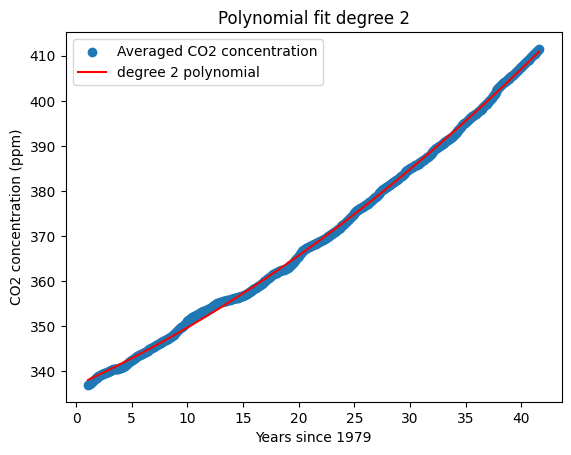

Error (degree 2 polynomial): 0.3785466547248009


In [12]:
# Compute the design matrix and perform the linear regression for the polynomial fit of degree 2
X_pol_2 = np.vstack((np.ones(len(x_)), x_, x_**2)).T
A_pol_2 = np.linalg.lstsq(X_pol_2, tableau_numpy[12:, 2], rcond=None)[0]

# Display the coefficients of the polynomial fit
print(f"Coefficients of the polynomial fit: {A_pol_2}")

# Display the data cloud and the fitting polynomial curve
y_pol_2 = X_pol_2 @ A_pol_2
plt.scatter(x_, tableau_numpy[12:, 2], label='Averaged CO2 concentration')
plt.plot(x_, y_pol_2, color='red', label='degree 2 polynomial')
plt.xlabel('Years since 1979')
plt.ylabel('CO2 concentration (ppm)')
plt.title('Polynomial fit degree 2')
plt.legend()
plt.show()

# Display the error of the polynomial fit
err_pol_2 = np.mean((tableau_numpy[12:, 2] - y_pol_2)**2)
print(f"Error (degree 2 polynomial): {err_pol_2}")

Coefficients of the polynomial fit of degree 3: [3.35843586e+02 1.39593539e+00 3.00099347e-04 2.40850779e-04]


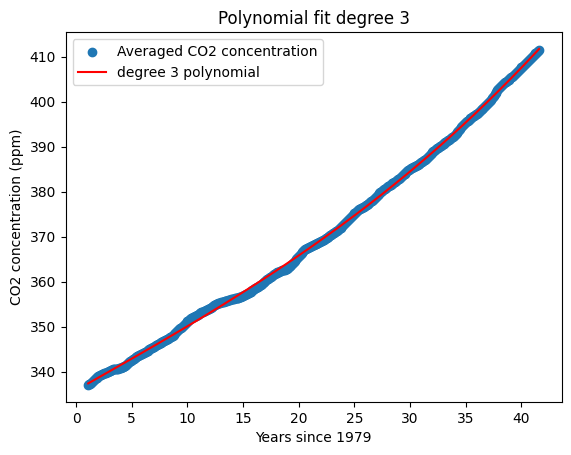

Error (degree 3 polynomial): 0.28600291774452474


In [13]:
# Compute the design matrix and perform the linear regression for the polynomial fit of degree 3
X_pol_3 = np.vstack((np.ones(len(x_)), x_, x_**2, x_**3)).T
A_pol_3 = np.linalg.lstsq(X_pol_3, tableau_numpy[12:, 2], rcond=None)[0]

# Display the coefficients of the polynomial fit of degree 3
print(f"Coefficients of the polynomial fit of degree 3: {A_pol_3}")

# Display the data cloud and the fitting polynomial curve of degree 3
y_pol_3 = X_pol_3 @ A_pol_3
plt.scatter(x_, tableau_numpy[12:, 2], label='Averaged CO2 concentration')
plt.plot(x_, y_pol_3, color='red', label='degree 3 polynomial')
plt.xlabel('Years since 1979')
plt.ylabel('CO2 concentration (ppm)')
plt.title('Polynomial fit degree 3')
plt.legend()
plt.show()

# Display the error of the polynomial fit of degree 3
err_pol_3 = np.mean((tableau_numpy[12:, 2] - y_pol_3)**2)
print(f"Error (degree 3 polynomial): {err_pol_3}")

Coefficients of the polynomial fit of degree 4: [ 3.35372610e+02  1.57939993e+00 -1.80455218e-02  8.99241399e-04
 -7.71551248e-06]


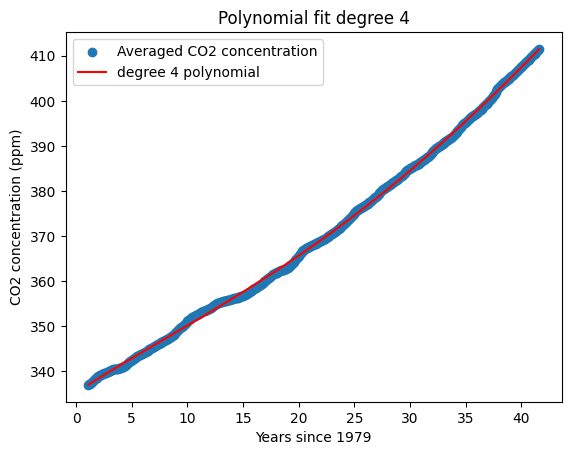

Error (degree 4 polynomial): 0.2760734956797968


In [14]:
# Compute the design matrix and perform the linear regression for the polynomial fit of degree 4
X_pol_4 = np.vstack((np.ones(len(x_)), x_, x_**2, x_**3, x_**4)).T
A_pol_4 = np.linalg.lstsq(X_pol_4, tableau_numpy[12:, 2], rcond=None)[0]

# Display the coefficients of the polynomial fit of degree 4
print(f"Coefficients of the polynomial fit of degree 4: {A_pol_4}")

# Display the data cloud and the fitting polynomial curve of degree 4
y_pol_4 = X_pol_4 @ A_pol_4
plt.scatter(x_, tableau_numpy[12:, 2], label='Averaged CO2 concentration')
plt.plot(x_, y_pol_4, color='red', label='degree 4 polynomial')
plt.xlabel('Years since 1979')
plt.ylabel('CO2 concentration (ppm)')
plt.title('Polynomial fit degree 4')
plt.legend()
plt.show()

# Display the error of the polynomial fit of degree 4
err_pol_4 = np.mean((tableau_numpy[12:, 2] - y_pol_4)**2)
print(f"Error (degree 4 polynomial): {err_pol_4}")

**Q10:** As we increase the degree of the polynomial, we add more coefficients, so the model becomes more flexible and can fit the data more closely, which reduces the error. However, using a very high degree like 1000 would cause overfitting; the model would fit the existing data perfectly but would give completely wrong predictions outside of it.

# 4 Predict the future

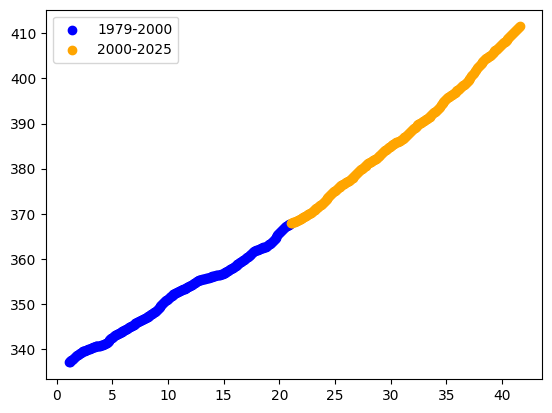

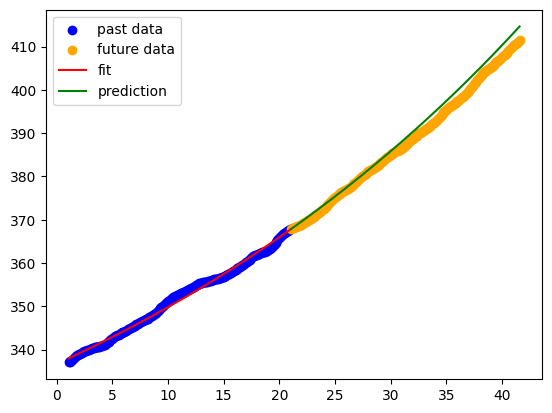

Error on future data: 3.048514661274024


In [15]:
# Create the past and future data for the averaged CO2 concentration
x_past = x_[x_ <= 21]
y_past = tableau_numpy[12:, 2][x_ <= 21]

x_future = x_[x_ > 21]
y_future = tableau_numpy[12:, 2][x_ > 21]

# Display the past and future data (use two different colors)
plt.scatter(x_past, y_past, color='blue', label='1979-2000')
plt.scatter(x_future, y_future, color='orange', label='2000-2025')
plt.legend()
plt.show()

# Fit exponential model on past data only
y_past_aux = np.log(y_past - 280)
cov_past = np.cov(x_past, y_past_aux, bias=True)
beta_past = cov_past[0, 1] / cov_past[0, 0]
alpha_past = np.exp(np.mean(y_past_aux) - beta_past * np.mean(x_past))

# Display the data cloud and the fitting curve for the past and future data
y_past_pred = 280 + alpha_past * np.exp(beta_past * x_past)
y_future_pred = 280 + alpha_past * np.exp(beta_past * x_future)
plt.scatter(x_past, y_past, color='blue', label='past data')
plt.scatter(x_future, y_future, color='orange', label='future data')
plt.plot(x_past, y_past_pred, color='red', label='fit')
plt.plot(x_future, y_future_pred, color='green', label='prediction')
plt.legend()
plt.show()

# Display the error of the fit for the future data
err_future = np.mean((y_future - y_future_pred)**2)
print(f"Error on future data: {err_future}")

**Q11:** I chose the exponential model as it had the best error on the full dataset (0.40). Trained on 1979-2000 data, alpha = 57.05451657528098 and beta = 0.020196475606141913 . The error on the testing set (2000 to 2025) is 3.05, which is reasonable for a 25-year prediction.

## 5 (Bonus) The periodic component

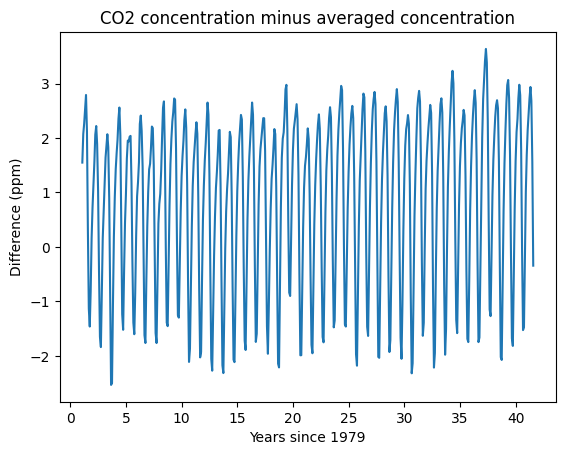

In [17]:
y_ = tableau_numpy[12:, 1] - tableau_numpy[12:, 2]
plt.plot(x_, y_)
plt.xlabel('Years since 1979')
plt.ylabel('Difference (ppm)')
plt.title('CO2 concentration minus averaged concentration')
plt.show()

**Q12:** The difference shows a clear periodic oscillation that repeats every year which means the data goes up and down in a regular cycle around zero.

**Q13:** A periodicity of 1 means the phenomenon repeats every year. This is because of the the seasons: in spring and summer, plants absorb more CO2 through photosynthesis, which lowers the concentration. In autumn and winter they stop, so CO2 rises again.

**Q14:** Using the formula sin(a+b) = sin(a)cos(b) + cos(a)sin(b), we can rewrite A·sin(2*pi*x + phi) as a linear combination of sin(2*pi*x) and cos(2*pi*x). So we build a design matrix with these two columns and apply linear regression to get the coefficients, from which we can recover A and phi.

A = 2.0401652422602203, phi = 0.011651906834341254


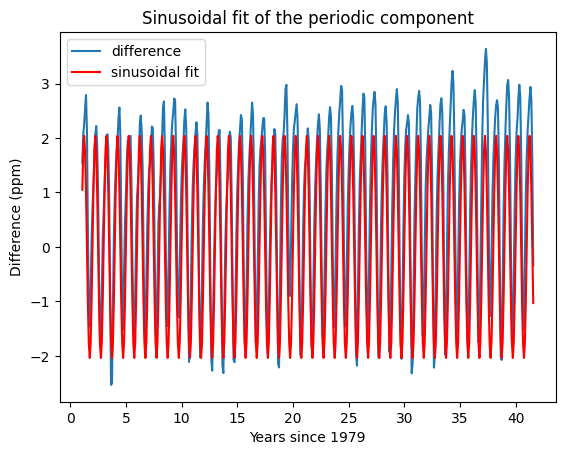

Error (sinusoidal fit): 1.072779650266544


In [18]:
# Create the design matrix for the phase of x
X_sin = np.vstack((np.sin(2 * np.pi * x_), np.cos(2 * np.pi * x_))).T

# Perform the linear regression
A_sin = np.linalg.lstsq(X_sin, y_, rcond=None)[0]

# Compute and display A and phi
A = np.sqrt(A_sin[0]**2 + A_sin[1]**2)
phi = np.arctan2(A_sin[1], A_sin[0])
print(f"A = {A}, phi = {phi}")

# Plot the fitting model on top of the data
y_sin_pred = A * np.sin(2 * np.pi * x_ + phi)
plt.plot(x_, y_, label='difference')
plt.plot(x_, y_sin_pred, color='red', label='sinusoidal fit')
plt.xlabel('Years since 1979')
plt.ylabel('Difference (ppm)')
plt.title('Sinusoidal fit of the periodic component')
plt.legend()
plt.show()

# Display the error of the sinusoidal fit
err_sin = np.mean((y_ - y_sin_pred)**2)
print(f"Error (sinusoidal fit): {err_sin}")

**Q15:** The sinusoidal model fits the periodic component well with an error of 1.072779650266544 . This confirms that the seasonal variation in CO2 concentration can be well approximated by a simple sine wave with a yearly period.